In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cross_decomposition import PLSRegression
import scipy
import ECoG
import pandas as pd
from Models import *
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

Использовала данные 25 с сайта: http://bnci-horizon-2020.eu/database/data-sets

In [88]:
raw = mne.io.read_raw_gdf('S01_ME\motorexecution_subject1_run1.gdf');

Extracting EDF parameters from C:\Users\alsah\Documents\PLS\S01_ME\motorexecution_subject1_run1.gdf...
GDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\alsah\anaconda3\lib\site-packages\mne\io\edf\edf.py:996: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  etmode = np.fromstring(etmode, np.uint8).tolist()[0]
<ipython-input-88-25e2885e38e9>:1: RuntimeWarning: 3 channel names are too long, have been truncated to 15 characters:
['ShoulderAdductio', 'ShoulderFlexionE', 'ShoulderRotation']
  raw = mne.io.read_raw_gdf('S01_ME\motorexecution_subject1_run1.gdf');
<ipython-input-88-25e2885e38e9>:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'eeg'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_gdf('S01_ME\motorexecution_subject1_run1.gdf');


In [3]:
n_time_samps = raw.n_times
time_secs = raw.times
ch_names = raw.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
print('the (cropped) sample data object has {} time samples and {} channels.'
      ''.format(n_time_samps, n_chan))
print('The last time sample is at {} seconds.'.format(time_secs[-1]))
print('The first few channel names are {}.'.format(', '.join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print('bad channels:', raw.info['bads'])  # chs marked "bad" during acquisition
print(raw.info['sfreq'], 'Hz')            # sampling frequency
print(raw.info['description'], '\n')      # miscellaneous acquisition info

print(raw.info)

the (cropped) sample data object has 164864 time samples and 96 channels.
The last time sample is at 321.998046875 seconds.
The first few channel names are eeg-0, eeg-1, eeg-2.

bad channels: []
512.0 Hz
None 

<Info | 7 non-empty values
 bads: []
 ch_names: eeg-0, eeg-1, eeg-2, eeg-3, eeg-4, eeg-5, eeg-6, eeg-7, eeg-8, ...
 chs: 96 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2015-05-26 15:42:48 UTC
 nchan: 96
 projs: []
 sfreq: 512.0 Hz
>


In [4]:
EEG_data = raw.get_data()

In [15]:
df = raw.to_data_frame(picks=['eeg'])
df = df.iloc[20:-1000,:]

In [16]:
df['time'] = df['time'].apply(lambda x: x /1000)

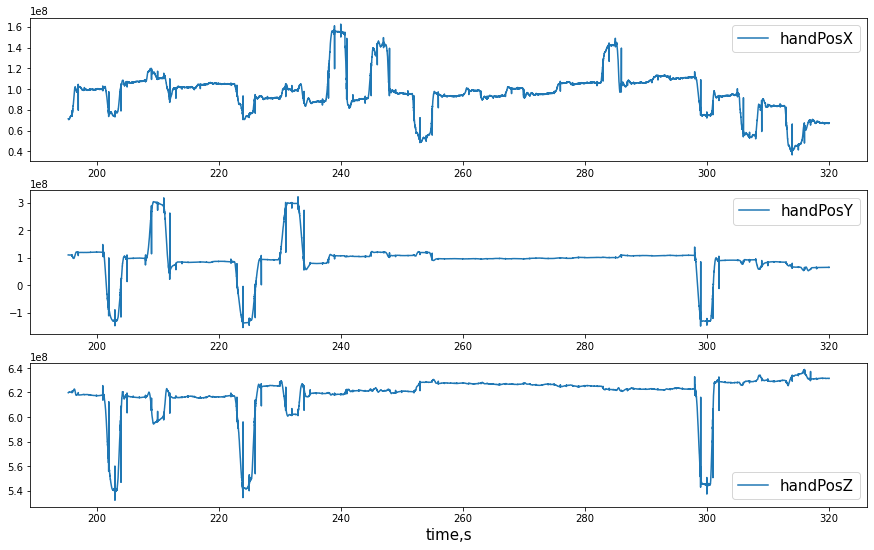

In [36]:
fig,ax = plt.subplots(3,1,figsize = (15,9))
ax[0].plot(df.iloc[100000:200000,0],df.iloc[100000:200000,84],label = 'handPosX')
ax[1].plot(df.iloc[100000:200000,0],df.iloc[100000:200000,85],label = 'handPosY')
ax[2].plot(df.iloc[100000:200000,0],df.iloc[100000:200000,86],label = 'handPosZ')
ax[0].legend(fontsize=15)
ax[1].legend(fontsize=15)
ax[2].legend(fontsize=15)
ax[2].set_xlabel('time,s',fontsize=15)
plt.show();

In [70]:
X = df.iloc[:,0:62].values
Y = df.iloc[:,[0,84,85,86]].values
data = ECoG.ECoG(X,Y,downsample = True)
filtered = data.bandpass_filter(lowcut=0.2,highcut=60,fs = 100,inplace=True)

In [81]:
freq = np.array([i for i in range(10,150,15)]) 
scalo, motion,time = data.scalo(1,freq,start = 0,end = 3000)

In [72]:
X = scalo.reshape((scalo.shape[0],scalo.shape[1]*scalo.shape[2]*scalo.shape[3]))

In [80]:
model = PLSRegression(n_components = 40)
model.fit(X,motion)
Y_pred = model.predict(X)

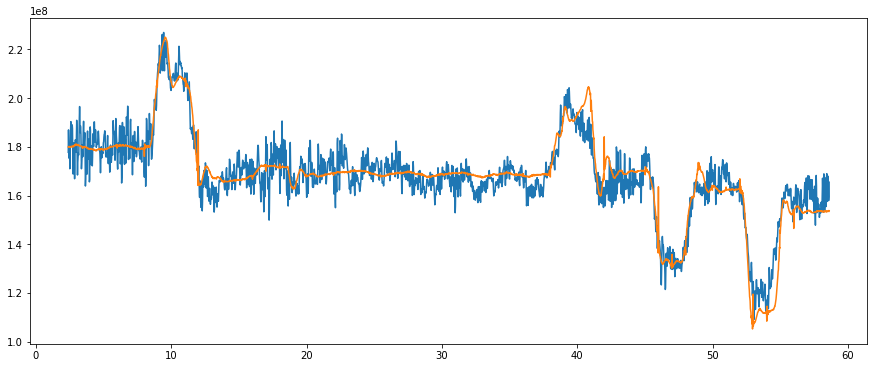

In [82]:
plt.figure(figsize = (15,6))
plt.plot(time,Y_pred[:,0])
plt.plot(time,motion[:,0])

In [83]:
X.shape

(2880, 7320)

In [89]:
from tqdm import tqdm_notebook

def metric_nmse(X, Y, est=None):
    if est is None:
        est = LinearRegression()
        est.fit(X, Y)
    Y_pred = est.predict(X)
    Y_base = Y.mean(axis=0)
    return np.mean(np.sqrt(np.mean((Y - Y_pred) ** 2, axis=0)) / np.sqrt(np.mean((Y - Y_base) ** 2, axis=0)))

X_train, X_test = X[:2000,:], X[2000:,]
Y_train, Y_test = motion[:2000,:], motion[2000:,:]
rmse = []
for k in tqdm_notebook(range(1, 100)):
    pls = PLSRegression(n_components=k)
    pls.fit(X_train, Y_train)
    tr = metric_nmse(X_train, Y_train, pls)
    te = metric_nmse(X_test, Y_test, pls)
    rmse.append((k, tr, te))

C:\Users\alsah\anaconda3\lib\site-packages\ipykernel_launcher.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  


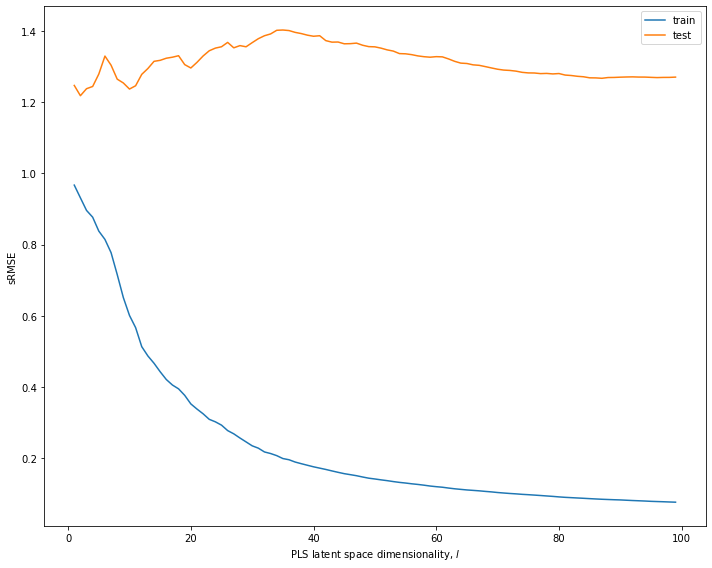

In [90]:
x = [r[0] for r in rmse]
y1 = np.array([r[1] for r in rmse])
y2 = np.array([r[2] for r in rmse])

plt.figure(figsize=(10, 8))

plt.plot(x, y1, label='train')

plt.plot(x, y2, label='test')

plt.ylabel(r'sRMSE')
plt.xlabel(r'PLS latent space dimensionality, $l$')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()